# مسئلهٔ ۱ — تحلیل خطا و انتخاب آستانهٔ تصمیم

مدل برای هر ویدئو یک احتمال مثبت‌بودن تولید می‌کند. آستانهٔ ۰.۵ یک انتخاب پیش‌فرض است؛ در این نوت‌بوک اثر آستانه‌های مختلف بر F1، precision، recall و false positive بررسی می‌شود.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,
)

DATA_ROOT = Path(r'P:\NexarCollisionData')
MODEL_DIR = DATA_ROOT / 'models'
predictions = pd.read_csv(MODEL_DIR / 'resnet18_validation_predictions.csv')
assert len(predictions) == 120
assert predictions['video_id'].nunique() == 120
predictions.head()

,video_id,label,positive_probability,prediction
0,14,1,0.542827,1
1,29,1,0.274635,0
2,31,1,0.763241,1
3,32,1,0.880159,1
4,56,1,0.703052,1


In [2]:
thresholds = np.arange(0.05, 0.96, 0.01)
results = []

for threshold in thresholds:
    predicted = (predictions['positive_probability'] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(predictions['label'], predicted, labels=[0, 1]).ravel()
    results.append({
        'threshold': threshold,
        'f1': f1_score(predictions['label'], predicted, zero_division=0),
        'accuracy': accuracy_score(predictions['label'], predicted),
        'precision': precision_score(predictions['label'], predicted, zero_division=0),
        'recall': recall_score(predictions['label'], predicted, zero_division=0),
        'false_positives': fp,
        'false_negatives': fn,
    })

threshold_results = pd.DataFrame(results)
best_by_f1 = threshold_results.loc[threshold_results['f1'].idxmax()]
print('Best threshold by F1:')
display(best_by_f1.to_frame().T)

Best threshold by F1:


,threshold,f1,accuracy,precision,recall,false_positives,false_negatives
30,0.35,0.72956,0.641667,0.585859,0.966667,41.0,2.0


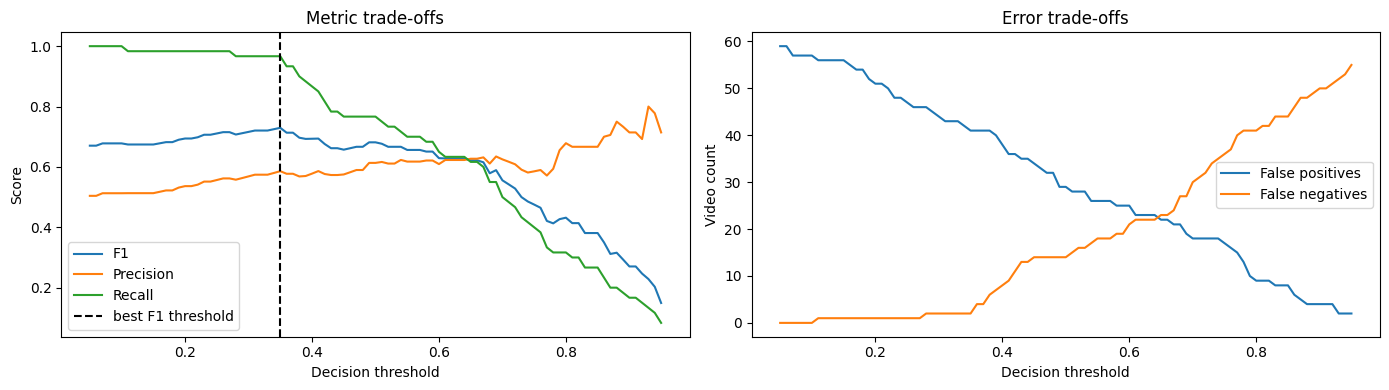

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(threshold_results['threshold'], threshold_results['f1'], label='F1')
axes[0].plot(threshold_results['threshold'], threshold_results['precision'], label='Precision')
axes[0].plot(threshold_results['threshold'], threshold_results['recall'], label='Recall')
axes[0].axvline(best_by_f1['threshold'], color='black', linestyle='--', label='best F1 threshold')
axes[0].set(xlabel='Decision threshold', ylabel='Score', title='Metric trade-offs')
axes[0].legend()

axes[1].plot(threshold_results['threshold'], threshold_results['false_positives'], label='False positives')
axes[1].plot(threshold_results['threshold'], threshold_results['false_negatives'], label='False negatives')
axes[1].set(xlabel='Decision threshold', ylabel='Video count', title='Error trade-offs')
axes[1].legend()
plt.tight_layout()
plt.show()

In [4]:
best_threshold = float(best_by_f1['threshold'])
best_prediction = (predictions['positive_probability'] >= best_threshold).astype(int)
predictions['prediction_at_best_f1_threshold'] = best_prediction

threshold_results.to_csv(MODEL_DIR / 'resnet18_threshold_analysis.csv', index=False)
predictions.to_csv(MODEL_DIR / 'resnet18_validation_predictions_with_threshold.csv', index=False)
(MODEL_DIR / 'resnet18_decision_threshold.json').write_text(
    json.dumps({'threshold': best_threshold, 'selection_metric': 'validation_f1'}, indent=2),
    encoding='utf-8',
)

print('Saved threshold:', best_threshold)
print('Confusion matrix at the selected threshold:')
print(confusion_matrix(predictions['label'], best_prediction, labels=[0, 1]))

Saved threshold: 0.35000000000000003
Confusion matrix at the selected threshold:
[[19 41]
 [ 2 58]]


## تفسیر

انتخاب آستانه باید با کاربرد سامانه هماهنگ باشد. اگر از دست‌دادن تصادف خطرناک‌تر است، recall بالاتر ارزش بیشتری دارد. اگر هشدار اشتباه هزینه‌ساز است، آستانهٔ بالاتر و false positive کمتر مناسب‌تر است. برای گزارش پروژه، هر دو trade-off را توضیح دهید.